# aerialdrm Hurricane Model

Explanation and demo

In [23]:
from dronelib.contingencymanagement.aircraft import ContingencyAircraftArchitecture, plot_flightpath
from fmdtools.define.architecture.function import FunctionArchitectureGraph

The hurricane aircraft architecture follows our desired FRDL architecture:

In [24]:
ha = ContingencyAircraftArchitecture()
ha

contingencyaircraftarchitecture ContingencyAircraftArchitecture
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force=Force(s=(weight=1.0, contact_support=0.0, lift_support=1.0))
- electricity=Electricity(s=(charge=100.0, voltage_high=1.0, current_high=1.0, power_high=False, voltage_low=1.0, cur...
- trajectories=Trajectories(s=(x=10.0, goal_x=10.0, dx=0.0, y=10.0, goal_y=10.0, dy=0.0, z=0.0, goal_z=0.0, dz=0.0))
- environment=ContingencyEnvironment(c=(), ga=())
FXNS:
- conditions=ContingencyConditions()
- control_flight=ContingencyControlFlight(s=(flightplan=((10.0, 10.0), (50.0, 10.0), (50.0, 100.0), (100.0, 100.0)), ...
- aviate=ContingencyAviate(m=(mode='idle', faults=set(), sub_faults=False))
- store_and_supply_ee=StoreAndSupplyElectricity(m=(mode='charged', faults=set(), sub_faults=False))
- perceive_environment=PerceiveEnvironment(m=(mode='nominal', faults=set(), sub_faults=False))
- hold_payload=HoldPayload(m=(mode='nominal', fau

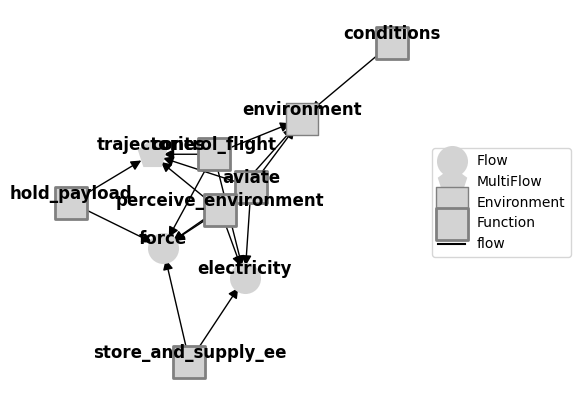

In [25]:
fg = FunctionArchitectureGraph(ha)
pos = {'hurricaneaircraftarchitecture.flows.force': [0.53, 0.25],
       'hurricaneaircraftarchitecture.flows.electricity': [-0.23, -0.26],
       'hurricaneaircraftarchitecture.flows.trajectories': [-0.25, 0.31],
       'hurricaneaircraftarchitecture.flows.environment': [-0.23, 0.81],
       'hurricaneaircraftarchitecture.fxns.control_flight': [-0.79, -0.06],
       'hurricaneaircraftarchitecture.fxns.conditions': [-0.30, 1.1],
       'hurricaneaircraftarchitecture.fxns.aviate': [-0.79, 0.65],
       'hurricaneaircraftarchitecture.fxns.store_and_supply_ee': [0.15, -0.66],
       'hurricaneaircraftarchitecture.fxns.perceive_environment': [0.49, 0.61],
       'hurricaneaircraftarchitecture.fxns.hold_payload': [0.72, -0.44]}
fg.set_edge_labels(title='')
fg.set_pos(**pos)
fig, ax = fg.draw(figsize=(5,5))
fig.savefig("hac_arch.pdf",  bbox_inches='tight')

In [26]:
# %matplotlib qt5
# fg.move_nodes()
# %matplotlib inline

## Environment

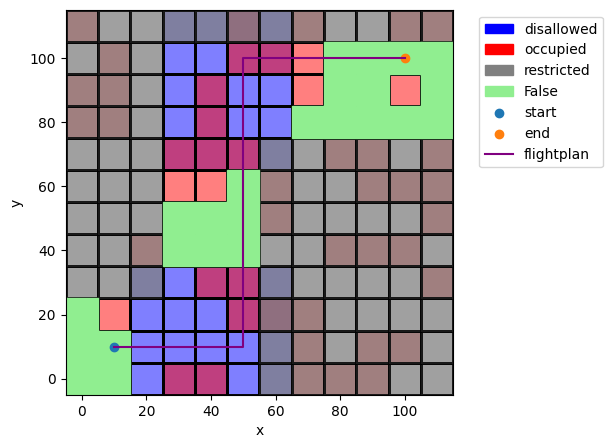

In [27]:
from dronelib.contingencymanagement.environment import properties, collections
from fmdtools.analyze.common import consolidate_legend
fig, ax = ha.flows['environment'].c.show(properties=properties, collections=collections)
ax.scatter([10], [10], label="start")
ax.scatter([100], [100], label="end")
xs = [x[0] for x in ha.p.flightplan]
ys = [x[1] for x in ha.p.flightplan]
ax.plot(xs, ys, label="flightplan", color="purple")
consolidate_legend(ax)

## Simulation

In [28]:
from fmdtools.sim import propagate
res, hist = propagate.nominal(ha)

res

tend.classify.faultmodes:          set()
tend.classify.unsuitable_landing:  False
tend.classify.disallowed_landing:  False
tend.classify.occupied_landing:    False
tend.classify.restricted_landing:  False
tend.classify.restricted_flight:   False
tend.classify.mission_complete:     True
tend.classify.landing_damage:      False
tend.classify.crash:               False

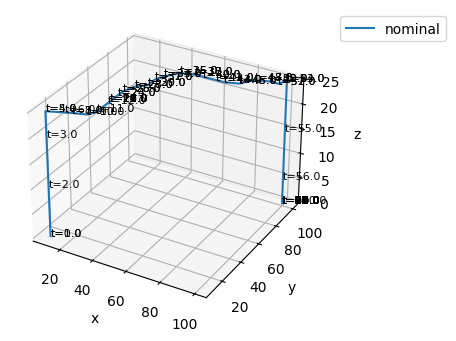

In [29]:
fig, ax = hist.plot_trajectories('trajectories.s.x',
                                 'trajectories.s.y',
                                 'trajectories.s.z',
                                  time_groups='nominal', time_ticks=1.0)

## Fault Scenarios

### Loss of Control

In [30]:
res, hist = propagate.one_fault(ha, 'control_flight', 'loss', 9, to_return=['classify', 'graph'])
res

nominal.tend.classify.faultmodes:  set()
nominal.tend.classif               False
nominal.tend.classif               False
nominal.tend.classify.occupied_landing: False
nominal.tend.classif               False
nominal.tend.classif               False
nominal.tend.classify.mission_complete: True
nominal.tend.classify.landing_damage: False
nominal.tend.classify.crash:       False
nominal.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x00000217ACD8F410>
control_flight_loss_{'aviate.crash', 'hold_payload.break', 'store_and_supply_ee.break', 'perceive_environment.break', 'control_flight.loss'}
control_flight_loss_                True
control_flight_loss_                True
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_               False
control_flight_loss_                True
control_flight_loss_                True
control_flight_loss_t9.tend.graph: 

In [31]:
graph = res.faulty.tend.graph

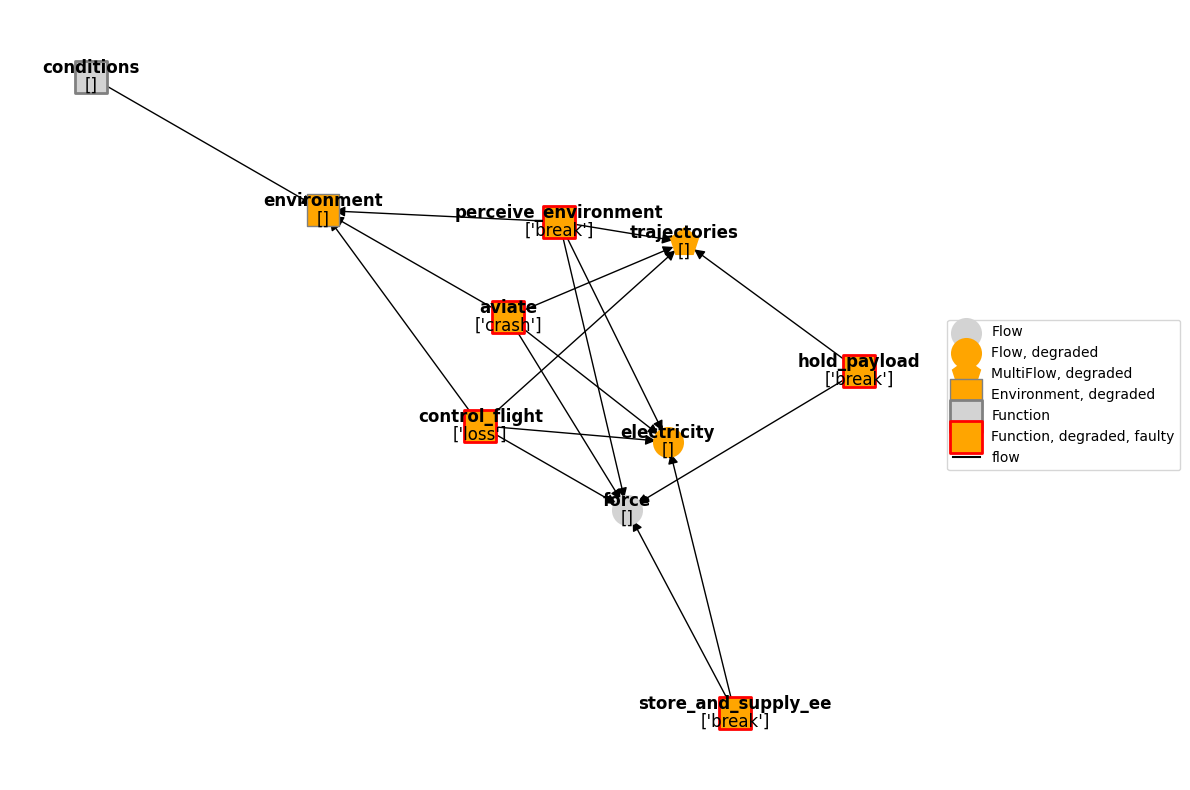

In [32]:
graph.set_pos(**pos)
graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
graph.set_edge_labels(title='')
graph.draw()
fig.savefig('arch_no_con.pdf')

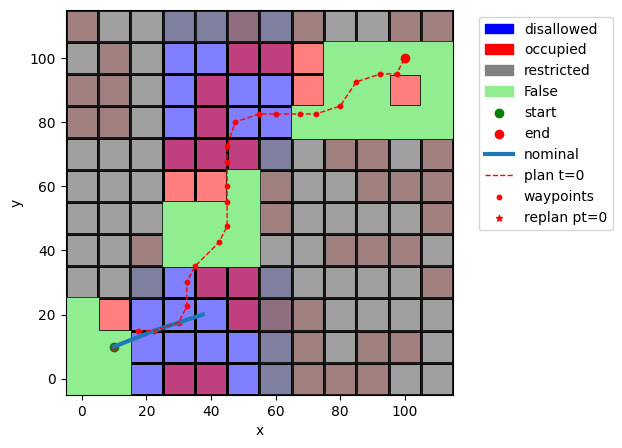

In [34]:
fig, ax = plot_flightpath(ha, hist.faulty)
fig.savefig('traj_no_con.pdf')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

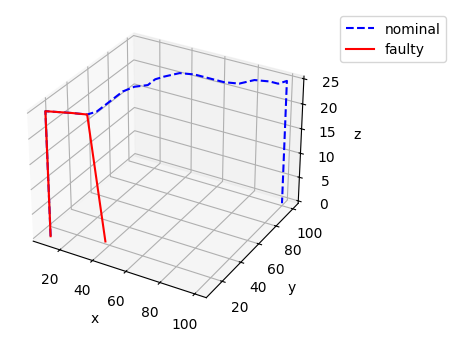

In [35]:
hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

### Battery Depletion

In [36]:
ha = ContingencyAircraftArchitecture(p={'depletion': 16.0})
res, hist = propagate.one_fault(ha, 'store_and_supply_ee', 'depletion', 16, to_return=['classify', 'graph'])

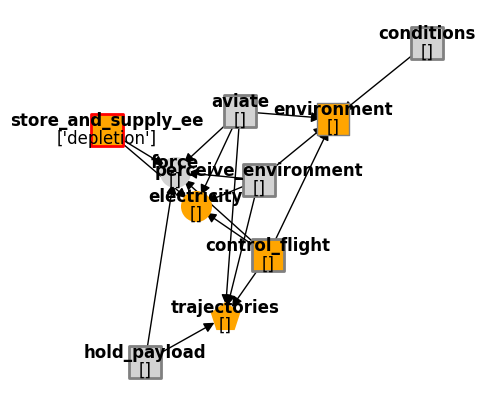

In [37]:
graph = res.faulty.tend.graph
graph.set_pos(**pos)
graph.set_node_labels(title='shortname', subtext='faults_and_indicators')
graph.set_edge_labels(title='')
fig, ax =graph.draw(figsize=(5,5), withlegend=False)
fig.savefig('arch_bat_depletion.pdf',  bbox_inches='tight')

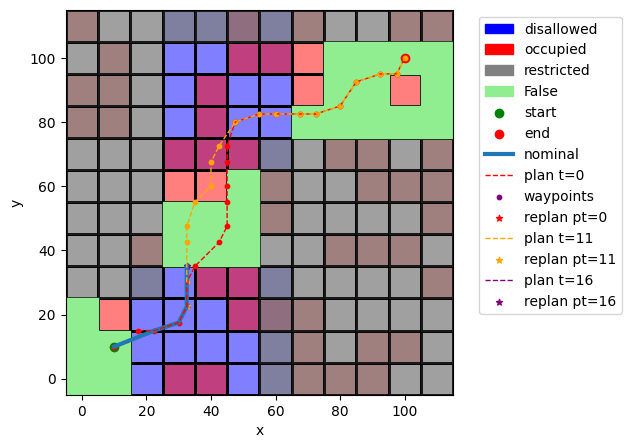

In [39]:
fig, ax = plot_flightpath(ha, hist.faulty)
fig.savefig('traj_bat_depletion.pdf')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

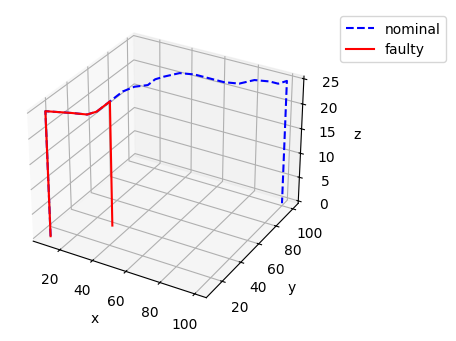

In [40]:
hist.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

## Statistical Simulation


Standard/25% depletion:

In [41]:
from fmdtools.analyze.phases import from_hist
pms = from_hist(hist.nominal)
pm = pms['store_and_supply_ee']

In [43]:
from fmdtools.sim.sample import FaultDomain, FaultSample

ha_25 = ContingencyAircraftArchitecture()
fd = FaultDomain(ha_25)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', args=(10,))
# fs.add_fault_phases('in_use', method='all')
fs

FaultSample of scenarios: 
 - store_and_supply_ee_depletion_t7p0
 - store_and_supply_ee_depletion_t12p0
 - store_and_supply_ee_depletion_t17p0
 - store_and_supply_ee_depletion_t22p0
 - store_and_supply_ee_depletion_t27p0
 - store_and_supply_ee_depletion_t32p0
 - store_and_supply_ee_depletion_t37p0
 - store_and_supply_ee_depletion_t42p0
 - store_and_supply_ee_depletion_t47p0
 - store_and_supply_ee_depletion_t52p0

In [44]:
res_25, hist_25 = propagate.fault_sample(ha_25, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:24<00:00,  2.45s/it]


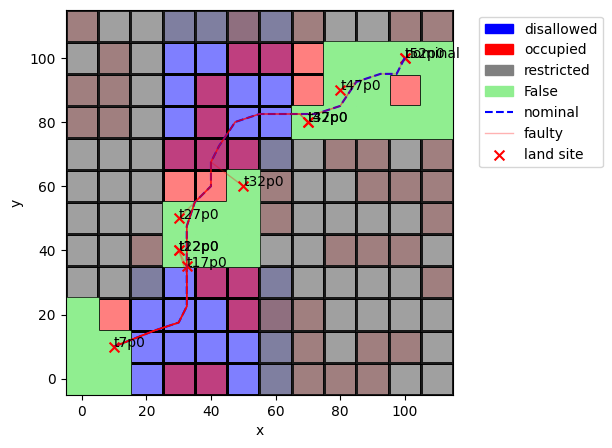

In [46]:
from dronelib.contingencymanagement.aircraft import plot_land_sites
fig, ax = plot_land_sites(ha_25, hist_25)

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

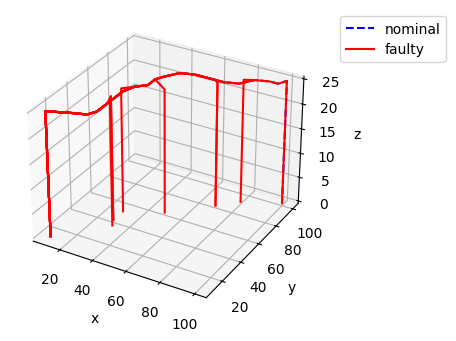

In [47]:
hist_25.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

16% depletion

In [49]:
ha_16 = ContingencyAircraftArchitecture(p={'depletion': 18.0})
fd = FaultDomain(ha_16)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use', args=(10,))
fs
res_16, hist_16 = propagate.fault_sample(ha_16, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:26<00:00,  2.65s/it]


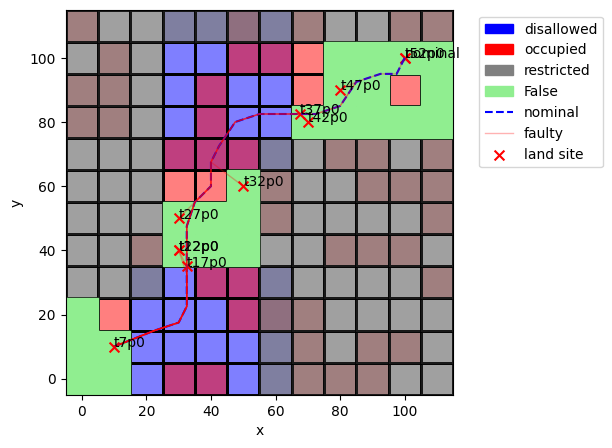

In [50]:
fig, ax = plot_land_sites(ha_16, hist_16)
fig.savefig('depletion_flightpath16.pdf',  bbox_inches='tight')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

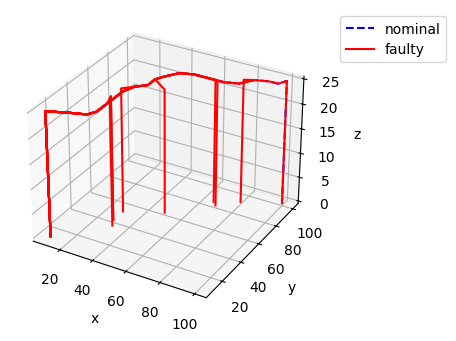

In [51]:
hist_16.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

0% depletion

In [53]:
ha_0 = ContingencyAircraftArchitecture(p={'depletion': 0.0})
fd = FaultDomain(ha_0)
fd.add_fault('store_and_supply_ee', 'depletion')

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use',  args=(10,))
fs
res_0, hist_0 = propagate.fault_sample(ha_0, fs)

SCENARIOS COMPLETE: 100%|██████████| 10/10 [00:02<00:00,  4.47it/s]


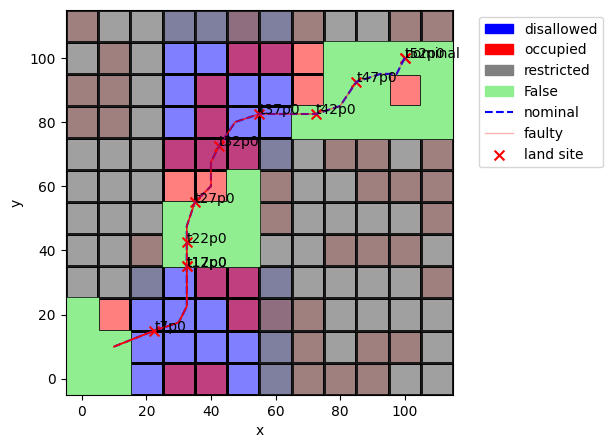

In [54]:
fig, ax = plot_land_sites(ha_0, hist_0)

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

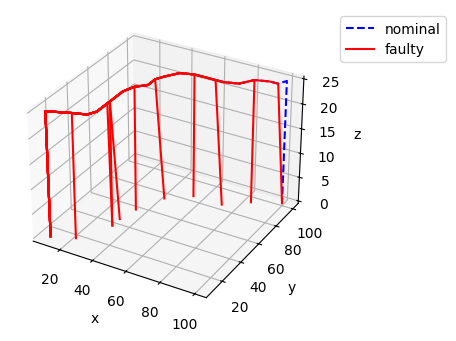

In [55]:
hist_0.plot_trajectories('trajectories.s.x', 'trajectories.s.y', 'trajectories.s.z')

In [56]:
from fmdtools.analyze.tabulate import FMEA, result_summary_fmea, Comparison
fm = FMEA(res_0, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm0 = fm.as_table()
fm0 = fm0.rename(index={'store_and_supply_ee': ''})
fm0 = fm0.rename(index={'depletion': 'depletion (0\%)'})
fm0

<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
C:\Users\dhulse\AppData\Local\Temp\1\ipykernel_16632\1470615140.py:5: SyntaxWarning: invalid escape sequence '\%'
  fm0 = fm0.rename(index={'depletion': 'depletion (0\%)'})


,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (0\%),0.1,0.9,0.3,0.2,1.0,1.0


In [57]:
fm = FMEA(res_16, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm16 = fm.as_table()
fm16 = fm16.rename(index={'store_and_supply_ee': ''})
fm16 = fm16.rename(index={'depletion': 'depletion (16\%)'})
fm16

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
C:\Users\dhulse\AppData\Local\Temp\1\ipykernel_16632\3927667149.py:4: SyntaxWarning: invalid escape sequence '\%'
  fm16 = fm16.rename(index={'depletion': 'depletion (16\%)'})


,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (16\%),0.1,0.2,0.0,0.0,0.0,0.0


In [58]:
fm = FMEA(res_25, fs, percent_metric=['mission_complete', 'unsuitable_landing', 'disallowed_landing', 'occupied_landing', 'landing_damage', 'crash'])
fm25 = fm.as_table()
fm25 = fm25.rename(index={'store_and_supply_ee': ''})
fm25 = fm25.rename(index={'depletion': 'depletion (25\%)'})
fm25

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
C:\Users\dhulse\AppData\Local\Temp\1\ipykernel_16632\358424544.py:4: SyntaxWarning: invalid escape sequence '\%'
  fm25 = fm25.rename(index={'depletion': 'depletion (25\%)'})


,,percent_mission_complete,percent_unsuitable_landing,percent_disallowed_landing,percent_occupied_landing,percent_landing_damage,percent_crash
,depletion (25\%),0.1,0.1,0.0,0.0,0.0,0.0


In [59]:
import pandas as pd
full_fm = pd.concat([fm0, fm16, fm25])
full_fm = full_fm*100
full_fm = full_fm.rename(columns = {'percent_mission_complete': 'mission complete',
                                    'percent_unsuitable_landing': 'unsuitable site',
                                    'percent_disallowed_landing': 'disallowed site',
                                    'percent_occupied_landing': 'occupied site',
                                    'percent_landing_damage': 'damaged',
                                    'percent_crash': 'crashed'})
full_fm = full_fm.style.format(precision=1)
full_fm

In [60]:
print(full_fm.to_latex())

\begin{tabular}{llrrrrrr}
 &  & mission complete & unsuitable site & disallowed site & occupied site & damaged & crashed \\
\multirow[c]{3}{*}{} & depletion (0\%) & 10.0 & 90.0 & 30.0 & 20.0 & 100.0 & 100.0 \\
 & depletion (16\%) & 10.0 & 20.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
 & depletion (25\%) & 10.0 & 10.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
\end{tabular}



## Statistical Simulation - New

In [61]:
from fmdtools.analyze.phases import from_hist
from fmdtools.sim import propagate
from fmdtools.sim.sample import FaultDomain, FaultSample

ha = ContingencyAircraftArchitecture()
res, hist = propagate.nominal(ha)
pms = from_hist(hist)
pm = pms['store_and_supply_ee']


fd = FaultDomain(ha)
fd.add_fault('store_and_supply_ee', 'depletion', '1', disturbances=(('electricity.s.charge', 1.0), ))
fd.add_fault('store_and_supply_ee', 'depletion', '10', disturbances=(('electricity.s.charge', 10.0), ))
fd.add_fault('store_and_supply_ee', 'depletion', '25', disturbances=(('electricity.s.charge', 25.0), ))

fs = FaultSample(fd, phasemap=pm)
fs.add_fault_phases('in_use',  args=(10,))
fs

res, hist = propagate.fault_sample(ha, fs)

SCENARIOS COMPLETE: 100%|██████████| 30/30 [00:54<00:00,  1.82s/it]


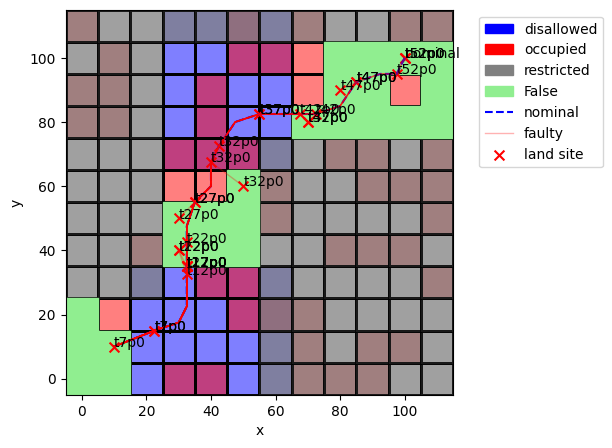

In [62]:
fig, ax = plot_land_sites(ha, hist)